In [5]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as trf
from pylab import rcParams
import warnings
from mlxtend.plotting import plot_decision_regions
from matplotlib.colors import ListedColormap
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles


In [45]:
X, y = make_circles(n_samples = 100, noise = 0.1, random_state = 31)

<Axes: >

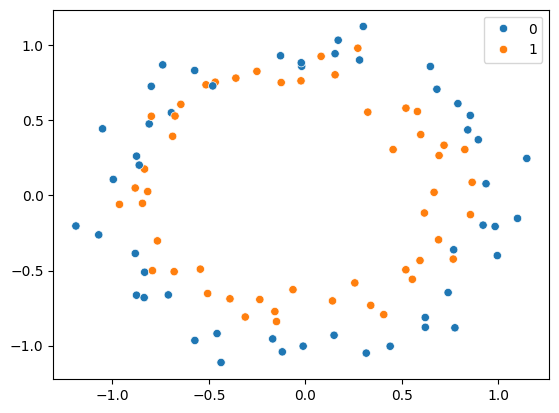

In [46]:
sns.scatterplot(x = X[:,0], y = X[:,1],hue=y)

In [47]:
X.shape

(100, 2)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 2)

In [14]:
model = Sequential()

model.add(Dense(256, input_dim = 2, activation = 'relu'))
model.add(Dense(1, activation = 'sigmoid'))

e:\Advance ML\Deep_Learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [16]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │           768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,025 (4.00 KB)

 Trainable params: 1,025 (4.00 KB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model.compile(loss = 'binary_crossentropy', optimizer = 'adam', metrics = ['accuracy'])

In [18]:
history = model.fit(X_train, y_train, validation_data = (X_test, y_test), epochs = 3500, verbose = 0)

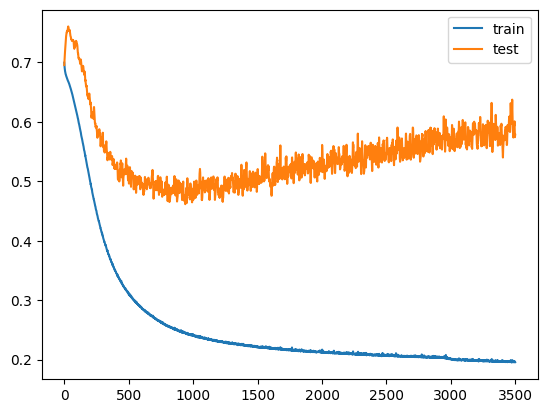

In [19]:
plt.plot(history.history['loss'], label = 'train')
plt.plot(history.history['val_loss'], label = 'test')
plt.legend()
plt.show()


9600/9600 ━━━━━━━━━━━━━━━━━━━━ 17s 2ms/step


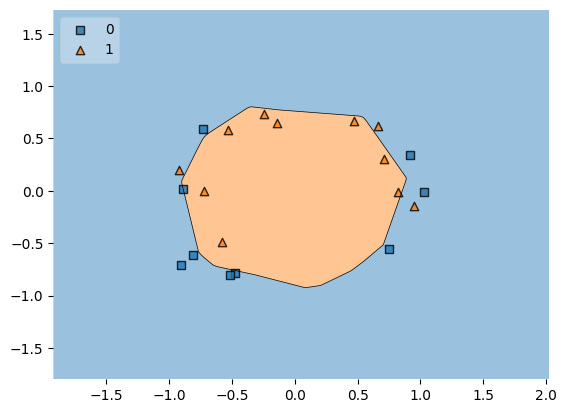

In [20]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend = 2)
plt.show()

## Early Stopping

In [49]:
model = Sequential()

model.add(Dense(256, input_dim=2, activation='relu'))
model.add(Dense(1, activation='sigmoid'))

e:\Advance ML\Deep_Learning\venv\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [50]:
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

In [51]:
callback = EarlyStopping(
    monitor = 'val_loss', 
    min_delta = 0.00001,
    patience=20,
    verbose = 1,
    mode = "auto",
    baseline = None,
    restore_best_weights = False

)

In [52]:
history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=3500, callbacks=callback)

Epoch 1/3500


3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 223ms/step - accuracy: 0.4625 - loss: 0.6971 - val_accuracy: 0.5000 - val_loss: 0.6939
Epoch 2/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.4750 - loss: 0.6945 - val_accuracy: 0.4500 - val_loss: 0.6951
Epoch 3/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5250 - loss: 0.6932 - val_accuracy: 0.4500 - val_loss: 0.6973
Epoch 4/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5125 - loss: 0.6924 - val_accuracy: 0.4500 - val_loss: 0.6984
Epoch 5/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step - accuracy: 0.5250 - loss: 0.6908 - val_accuracy: 0.4500 - val_loss: 0.6991
Epoch 6/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step - accuracy: 0.5125 - loss: 0.6903 - val_accuracy: 0.4500 - val_loss: 0.6996
Epoch 7/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.5250 - loss: 0.6892 - val_accuracy: 0.4500 - val_loss: 0.7008
Epoch 8/3500
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - accuracy: 0.5250 - loss: 0.6882 - val_accuracy: 0.4500 - val_loss: 0.7

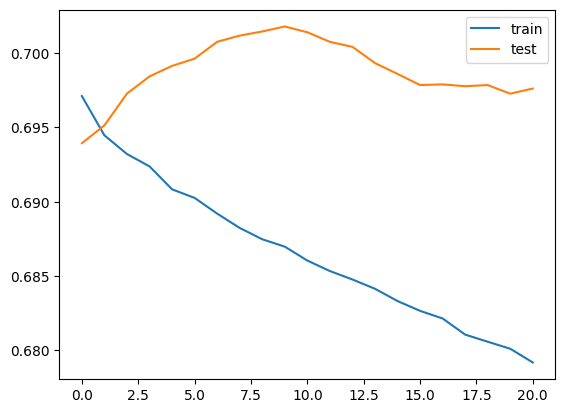

In [53]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='test')
plt.legend()
plt.show()

9600/9600 ━━━━━━━━━━━━━━━━━━━━ 16s 2ms/step


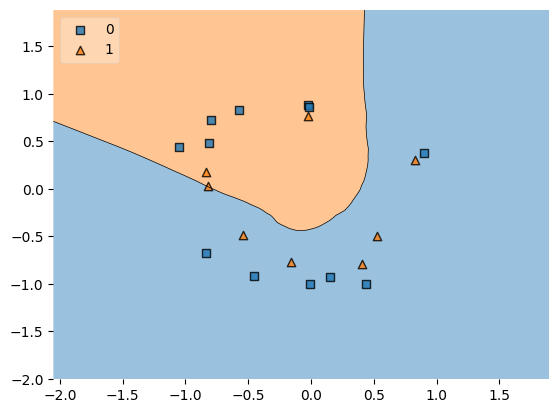

In [54]:
plot_decision_regions(X_test, y_test.ravel(), clf = model, legend=2)
plt.show()